# 1 PCR Data Analysis using Wastewater Monitoring

#### 1.0.1 Professor Polly Parks

##### **Estimated Time:** 30-40 minutes  
##### **Databook created by:** Ariana Ghimire   
##### **Article Citation:** ACS EST Water 2022, 2, 11, 1899–1909  
https://pubs.acs.org/doi/10.1021/acsestwater.1c00434

Today we will be examining a dataset (i.e. a table) and building a few graphs to demonstrate how using wastewater samples can monitor the spreading of diseases. Specifically, we are investigating the use of measuring RNA concentrations in wastewater to determine the spread of SARS-CoV2 during the pandemic. SARS-CoV2 is the ssRNA virus that causes COVID-19, which means there is ssRNA in its capsid. When people are infected with SARS-CoV2, some of the virus exits their body through their urine and fecal matter ending up in our wastewater systems (i.e. sewage). Epidemiologists figured out that if we sampled the wastewater we could predict the level of infected individuals in a location and potentially use this information to help prepare the local healthcare facilities for an increase in the number of patients.

The viruses are floating around in the wastewater, maybe whole or maybe in pieces. The water samples are filtered to remove all of the large fecal matter materials and cells, including bacteria. The filtered liquid would only contain viruses and small molecules (like DNA, RNA, and proteins). Researchers perform a RNA isolation to remove all of the RNA from the sample. This step is similar to a DNA isolation but instead purifies RNA molecules only. Next, the researchers perform a two step fancy PCR called **RT-qPCR**. Step one involves using the enzyme **reverse transcriptase (RT)** to convert the RNA in the sample into DNA molecules. Step two is a variation on PCR in which the specific amount of original pieces of DNA (previously the RNA) can be measured called **quantitative PCR (qPCR)**.

The researchers use specific primers that base pair to a gene found only in SARS-CoV2’s genome. If the gene is present, then PCR will occur and it means that SARS-CoV2 is present in the wastewater. If the gene is absent, then there is nothing for the primers to base pair to and PCR cannot occur (thus, SARS-CoV2 is not in the wastewater). As a control group, **pepper mild mottle virus (ppmv/PPMoV)** is also measured to indicate fecal matter presence in the wastewater. This measurement is used to normalize the amount of SARS-CoV2 to the amount of fecal matter in the water.


#### 1.0.2 Watch Me!

**Video title:** <a href="https://youtu.be/iu4s3Hbc_bw?si=NZ4FdK0s3-X92kyo" style="color:#1f3d2a; font-weight:600;">How does qPCR work?</a>

As mentioned in the video, when there is a high amount of DNA to begin with then the threshold (Ct) is met earlier. This would mean there is a high amount of SARS-CoV2 in that sample. If there is a low amount of DNA to begin with, then the threshold is met after more cycles relating to a lower amount of SARS-CoV2 in the wastewater.

In this notebook, we will analyze the normalized amount of SARS-CoV2 over time in the wastewater samples then compare this to the number of new cases that were occurring during the same time period. We will discuss the benefits and drawbacks to using wastewater sampling as a method to determine disease spread.


### 1.0.3 Notebook goals

In this notebook, students will: - explore a wastewater surveillance dataset - build two time-series
plots step by step - compare wastewater concentration trends to reported case trends - use a simple
regression model to test how wastewater measurements might relate to case counts


### 1.0.4 Import Dataset into Jupyter

***Click play/run on the section below.***

In [3]:
import sys
from pathlib import Path
import importlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, YouTubeVideo
import ipywidgets as widgets

# Load backend_data from SARS-CoV2 (works from repo root or this folder)
for _path in (Path.cwd(), Path.cwd() / "SARS-CoV2"):
    if (_path / "backend_data.py").is_file():
        if str(_path) not in sys.path:
            sys.path.insert(0, str(_path))
        break

import backend_data as _backend_data
importlib.reload(_backend_data)

from backend_data import (
    load_and_clean_wastewater_data,
    show_column_blurb_widget,
    plot_overlay_for_label,
    prepare_regression_model,
    explain_regression_for_students,
    plot_regression_fit,
    explain_regression_plot_for_students,
    show_prediction_explorer_widget,
)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

df, raw_path, clean_path = load_and_clean_wastewater_data(save_cleaned=True)
print("Loaded raw file:", raw_path)
print("Cleaned dataset shape:", df.shape)
print("Saved cleaned file as:", clean_path)
df.head()


Loaded raw file: biobot_kits_quant_data_duvalletetal2022.csv
Cleaned dataset shape: (2723, 7)
Saved cleaned file as: cleaned_wastewater_covid_data.csv


,sampling_date,normalized_conc_copies_per_L,pmmv_copies_per_mL_kit_raw,sarscov2_copies_per_mL_kit_raw,rolling_average_new_cases_centered,fig1_label,sars_to_pmmv_ratio
0,2020-04-22,1.117106e+06,7.842528e+04,240.025598,14.285714,A1,0.003061
1,2020-04-28,1.277460e+06,9.071607e+04,317.496411,122.000000,A1,0.003500
2,2020-05-04,9.817337e+05,6.383808e+04,171.704111,174.857143,A1,0.002690
3,2020-05-14,3.717074e+05,8.283056e+04,84.352702,228.571429,A1,0.001018
4,2020-05-18,1.390314e+05,1.128347e+06,429.796268,242.571429,A1,0.000381


### 1.0.5 What do these columns mean?

Run the section below. Then use the dropdown below to review each column. When you select a column name, a short explanation will appear.

In [4]:
show_column_blurb_widget()

Dropdown(description='Column:', layout=Layout(width='60%'), options=('sampling_date', 'normalized_conc_copies_…

Output()

### 1.0.6 Discussion Question 1

**In the context of wastewater sampling to determine disease spread, which three columns should we focus on? Why?**


*Type your answer here, replacing this text.*

### 1.1 Graph 1: Amount of SARS-CoV2 at a Single Wastewater Site

Instead of graphing all sampling sites together, you will now focus on **one wastewater sampling site at a time**. This makes the graph easier to read and helps us compare trends more clearly over time.

Each site is identified by a `fig1_label` value (examples: `"A1"`, `"B4"`, etc.).

You will build a line graph of:

- **x-axis:** `sampling_date`
- **y-axis:** `normalized_conc_copies_per_L`

First, choose a single site label. Then create a filtered dataframe containing only data from that site before plotting the graph.

Fill in the code below with the correct x-axis label, y-axis label, and graph title. Then click run.

If needed, click **Hint** to view an example structure.

<details>
<summary><strong>Hint:</strong></summary>

```python
label = "B4"  # pick one fig1_label from df["fig1_label"].unique()
site_df = df[df["fig1_label"] == label].sort_values("sampling_date")

plt.plot(site_df["x_column_name"], site_df["y_column_name"])
plt.xlabel("x_column_name")
plt.ylabel("y_column_name")
plt.title(f"Normalized SARS-CoV-2 concentration over time — {label}")
plt.show()
```

</details>

<details>
<summary><strong>Answer:</strong></summary>

```python
label = "B4"  # pick one fig1_label from df["fig1_label"].unique()
site_df = df[df["fig1_label"] == label].sort_values("sampling_date")

plt.plot(site_df["sampling_date"], site_df["normalized_conc_copies_per_L"])
plt.xlabel("sampling_date")
plt.ylabel("normalized_conc_copies_per_L")
plt.title(f"Normalized SARS-CoV-2 concentration over time — {label}")
plt.show()
```

</details>

In [ ]:
# Student exercise: replace the placeholder strings, then re-run.
label = "B4"  # pick one fig1_label from df["fig1_label"].unique()
site_df = df[df["fig1_label"] == label].sort_values("sampling_date")

plt.plot(site_df["..."], site_df["..."])
plt.xlabel("...")
plt.ylabel("...")
plt.title(f"Normalized SARS-CoV-2 concentration over time — {label}")
plt.show()


Replace x_col, y_col, and plot_title using the Hint above, then re-run this cell.


### 1.1.1 Discussion Question 2

**Describe the change over time in this data. What does it tell us about the amount of SARS-CoV2 in these samples? In addition from your understanding of PCR, how specific and accurate do you feel these results are?**


*Type your answer here, replacing this text.*

### 1.1.2 Graph 2: New Cases

Now, let’s build a second line graph but for the average number of new cases of COVID-19.

- **x-axis:** `sampling_date`
- **y-axis:** `rolling_average_new_cases_centered`

Use the **same `fig1_label`** as Graph 1 so you are comparing two trends for one location, not all sites mixed together.

The goal will be to compare the shape of this graph to the wastewater graph above. Edit the code then click run.

If needed, click Hint to drop down code for extra assistance.

<details>
<summary><strong>Hint:</strong></summary>

```python
label = "B4"  # use the same fig1_label as Graph 1
site_df = df[df["fig1_label"] == label].sort_values("sampling_date")

plt.plot(site_df["x_column_name"], site_df["y_column_name"])
plt.xlabel("x_column_name")
plt.ylabel("y_column_name")
plt.title(f"Average new cases over time — {label}")
plt.show()
```

</details>

<details>
<summary><strong>Answer:</strong></summary>

```python
label = "B4"  # use the same fig1_label as Graph 1
site_df = df[df["fig1_label"] == label].sort_values("sampling_date")

plt.plot(site_df["sampling_date"], site_df["rolling_average_new_cases_centered"])
plt.xlabel("sampling_date")
plt.ylabel("rolling_average_new_cases_centered")
plt.title(f"Average new cases over time — {label}")
plt.show()
```

</details>

In [8]:
# Student exercise: use the same site label as Graph 1, then fill in column names.
label = "B4"  # pick one fig1_label from df["fig1_label"].unique()
site_df = df[df["fig1_label"] == label].sort_values("sampling_date")

plt.plot(site_df["..."], site_df["..."])
plt.xlabel("...")
plt.ylabel("...")
plt.title(f"Average new cases over time — {label}")
plt.show()


Replace x_col, y_col, and plot_title using the Hint above, then re-run this cell.


### 1.1.3 Discussion Question 2

**Describe the change over time in this data. What does it tell us about the amount of new cases in these areas? How does it compare to your first graph?**

*Type your answer here, replacing this text.*

### 1.1.4 Graph 3: Overlay Graph

The graph below places both trends on one figure so the pattern is easier to compare.

Because the two variables are on different scales, this graph uses two y-axes:

- left y-axis for wastewater concentration
- right y-axis for rolling average new cases

Click run on the section below.

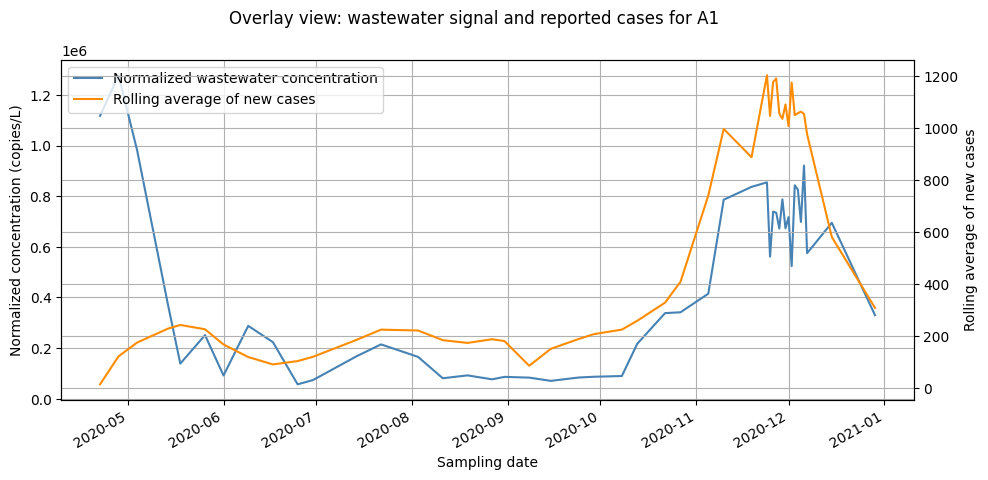

In [9]:
if "label_dropdown" in globals():
    selected_label = label_dropdown.value
else:
    selected_label = sorted(df["fig1_label"].dropna().unique().tolist())[0]

plot_overlay_for_label(df, selected_label)


### 1.1.5 Discussion Question 3

Use this overlay graph to evaluate whether wastewater monitoring appears useful for tracking community COVID-19 trends.

**In your response, address:** - whether wastewater concentration and reported case counts move
in a similar direction - whether higher wastewater measurements seem to line up with higher case
counts - whether wastewater might offer an earlier signal for community spread - how this could
help hospitals or public-health teams prepare - one limitation or caution when interpreting these
graphs

Write **3 to 5 sentences** and use evidence from your plots.

*Type your answer here, replacing this text.*

### 1.2 Simple prediction model

In this section, we will explore a basic regression model. This is a statistical tool to estimate a relationship between two variables. We will play with using wastewater concentration to estimate the rolling average of new reported cases.

This is **not** a clinical forecast tool.  
It is a simple classroom model for pattern-finding and interpretation.

Click run on the next section to explain the regression model we are using.

In [10]:
model_df, x, y, slope, intercept, r2 = prepare_regression_model(df)
explain_regression_for_students(slope, intercept, r2)


### Regression Summary

**Model equation**

`predicted_cases = 0.000201 * normalized_conc_copies_per_L + 181.055`

**Model fit**

`R^2 = 0.048`

### How to Read This

- **Best-fit line:** This line summarizes the overall trend between wastewater and case counts.
- **Slope (0.000201):** For each 1-unit increase in normalized wastewater concentration, predicted cases change by about `0.000201` on average.
- **Intercept (181.055):** This is the baseline model prediction when wastewater concentration is 0.
- **R^2 (0.048):** This is how much variation in case counts the line explains (`0` = very weak, `1` = very strong).


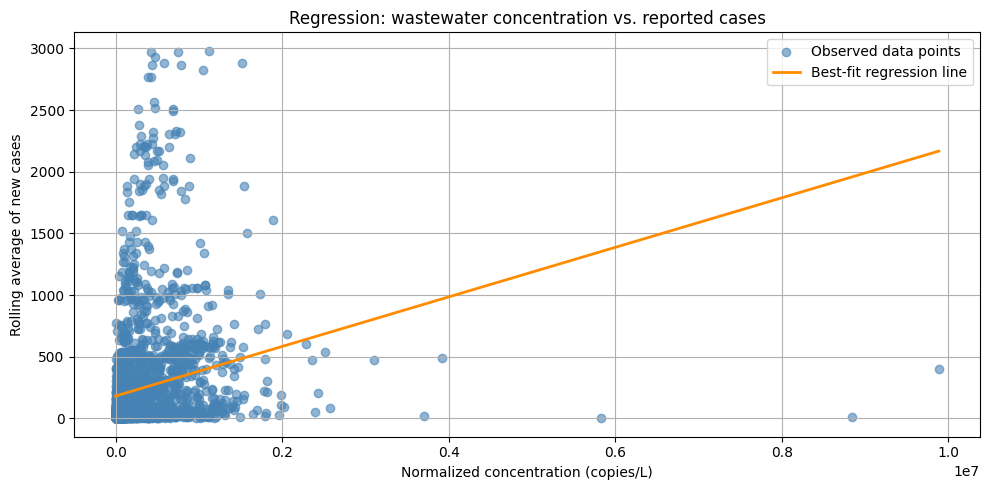


### How to Read This Graph

- **Blue dots:** each dot is one real observation from the dataset (wastewater level + reported cases).
- **Orange line:** this is the model's best-fit line showing the overall trend.
- **Upward slope:** if the line slopes up, higher wastewater values tend to go with higher reported case counts.
- **Distance from line:** dots far from the line show real-world noise and other factors not captured by this simple model.


In [11]:
if not all(name in globals() for name in ["model_df", "slope", "intercept"]):
    model_df, x, y, slope, intercept, r2 = prepare_regression_model(df)

plot_regression_fit(model_df, slope, intercept)
explain_regression_plot_for_students()


### 1.2.4 Discussion Question 4

Use the regression graph and prediction explorer above to answer the questions below.

1. What happens to predicted case counts when the wastewater signal increases?
2. How could hospitals or local health committees prepare if they start seeing those trends?
3. Does wastewater monitoring seem like a useful way to estimate case trends in a community?
4. What are some limits of this method?

Write 4 to 6 sentences.


*Type your answer here, replacing this text.*